In [1]:
#import kagglehub
#
## Download latest version
#path = kagglehub.dataset_download("isuranga/spam-genuine-mail-contents-dataset")
#
#print("Path to dataset files:", path)

In [2]:
import pandas as pd
# Wczytanie pliku
df = pd.read_csv('email_dataset_100k.csv')

EDA

In [3]:
# Podstawowy przegląd
print(df.shape)

print()
print("-" * 80)
print()

df.info()

print()
print("-" * 80)
print()

df.head()

(100000, 30)

--------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   raw_text                 100000 non-null  object 
 1   subject                  100000 non-null  object 
 2   body_plain               100000 non-null  object 
 3   body_html                42403 non-null   object 
 4   from_address             100000 non-null  object 
 5   from_domain              100000 non-null  object 
 6   reply_to                 29918 non-null   object 
 7   to_addresses             100000 non-null  object 
 8   cc_addresses             19902 non-null   object 
 9   date                     100000 non-null  object 
 10  hour_of_day              100000 non-null  int64  
 11  message_id               100000 non-null  object 
 12  in_reply_to        

,raw_text,subject,body_plain,body_html,from_address,from_domain,reply_to,to_addresses,cc_addresses,date,...,has_html,num_urls,num_emails_in_body,num_phone_numbers,contains_tracking_token,x_spam_score,user_agent,list_unsubscribe,language,label
0,"Subject: Release notes v2.6.4\nDear Vik,\n\nWe...",Release notes v2.6.4,"Dear Vik,\n\nWe received invoice 765713. It wi...",NaN,leo.wilson@adatum.net,adatum.net,NaN,kathy_taylor@notifications.net,NaN,2024-09-13T16:25:32,...,False,0,0,1,False,0.00,Microsoft Outlook,NaN,en,0
1,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour parcel has been flagged. To...",NaN,riya_miller313@proton.me,proton.me,NaN,olivia_wilson841@accounts-mail.com,NaN,2024-07-10T01:15:32,...,False,1,0,1,False,4.82,Mutt,NaN,en,1
2,"Subject: Follow-up: onboarding tasks\nHi Zack,...",Follow-up: onboarding tasks,"Hi Zack,\n\nHere are the notes from our meetin...",NaN,wendytaylor@cohosu.org,cohosu.org,NaN,vikwilliams@contoso.com,NaN,2024-04-23T16:20:32,...,False,0,0,0,False,0.00,Apple Mail,NaN,de,0
3,Subject: Limited-time offer: $119 cloud storag...,Limited-time offer: $119 cloud storage,"Attention Bob,\n\nWe detected unusual activity...",<html><body><h3>Limited-time offer: $119 cloud...,vik.brown@outlook.com,outlook.com,carol.johnson@icloud.com,carol.rodriguez@devops.local,NaN,2024-06-07T19:15:32,...,True,2,0,1,False,9.15,Mutt,NaN,it,1
4,"Subject: Weekly update - Legal\nTeam,\n\nNotes...",Weekly update - Legal,"Team,\n\nNotes from Legal daily standup attach...","<p>Team,<br/><br/>Notes from Legal daily stand...",grace_taylor@globalbank.com,globalbank.com,NaN,leo_wilson@notifications.net,NaN,2024-07-05T11:33:32,...,True,0,0,0,False,0.00,Thunderbird,NaN,it,0


In [4]:
#df[['subject', 'body_plain']].dtypes

In [5]:
# Feature engineering

# 1. Zamiana braków gdzie ma sens
df['attachment_types'] = df['attachment_types'].fillna('none')

# 2. Flagi istnienia
df['has_reply_to'] = df['reply_to'].notna().astype(int)
df['has_cc'] = df['cc_addresses'].notna().astype(int)
df['has_unsubscribe'] = df['list_unsubscribe'].notna().astype(int)
df['has_html_body'] = df['body_html'].notna().astype(int)
df['is_thread'] = df['in_reply_to'].notna().astype(int)

# Zamiana wyników SPF/DKIM/DMARC na 0/1
df['spf_pass'] = (df['spf_result'] == 'pass').astype(int)
df['dkim_pass'] = (df['dkim_result'] == 'pass').astype(int)
df['dmarc_pass'] = (df['dmarc_result'] == 'pass').astype(int)

# Tekst do TF-IDF
df['text'] = (
    df['subject'].fillna('') + ' ' + df['body_plain'].fillna('')
)

In [6]:
# Usuwanie duplikatów
df = df.drop_duplicates(subset=['text']).reset_index(drop=True) 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95109 entries, 0 to 95108
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   raw_text                 95109 non-null  object 
 1   subject                  95109 non-null  object 
 2   body_plain               95109 non-null  object 
 3   body_html                41140 non-null  object 
 4   from_address             95109 non-null  object 
 5   from_domain              95109 non-null  object 
 6   reply_to                 29442 non-null  object 
 7   to_addresses             95109 non-null  object 
 8   cc_addresses             18432 non-null  object 
 9   date                     95109 non-null  object 
 10  hour_of_day              95109 non-null  int64  
 11  message_id               95109 non-null  object 
 12  in_reply_to              13526 non-null  object 
 13  num_received_headers     95109 non-null  int64  
 14  received_origin_ip    

In [8]:
df

,raw_text,subject,body_plain,body_html,from_address,from_domain,reply_to,to_addresses,cc_addresses,date,...,label,has_reply_to,has_cc,has_unsubscribe,has_html_body,is_thread,spf_pass,dkim_pass,dmarc_pass,text
0,"Subject: Release notes v2.6.4\nDear Vik,\n\nWe...",Release notes v2.6.4,"Dear Vik,\n\nWe received invoice 765713. It wi...",NaN,leo.wilson@adatum.net,adatum.net,NaN,kathy_taylor@notifications.net,NaN,2024-09-13T16:25:32,...,0,0,0,0,0,1,0,0,0,"Release notes v2.6.4 Dear Vik,\n\nWe received ..."
1,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour parcel has been flagged. To...",NaN,riya_miller313@proton.me,proton.me,NaN,olivia_wilson841@accounts-mail.com,NaN,2024-07-10T01:15:32,...,1,0,0,0,0,0,1,0,0,"WINNER! Claim your reward Dear user,\n\nYour p..."
2,"Subject: Follow-up: onboarding tasks\nHi Zack,...",Follow-up: onboarding tasks,"Hi Zack,\n\nHere are the notes from our meetin...",NaN,wendytaylor@cohosu.org,cohosu.org,NaN,vikwilliams@contoso.com,NaN,2024-04-23T16:20:32,...,0,0,0,0,0,0,1,1,1,"Follow-up: onboarding tasks Hi Zack,\n\nHere a..."
3,Subject: Limited-time offer: $119 cloud storag...,Limited-time offer: $119 cloud storage,"Attention Bob,\n\nWe detected unusual activity...",<html><body><h3>Limited-time offer: $119 cloud...,vik.brown@outlook.com,outlook.com,carol.johnson@icloud.com,carol.rodriguez@devops.local,NaN,2024-06-07T19:15:32,...,1,1,0,0,1,0,0,0,0,Limited-time offer: $119 cloud storage Attenti...
4,"Subject: Weekly update - Legal\nTeam,\n\nNotes...",Weekly update - Legal,"Team,\n\nNotes from Legal daily standup attach...","<p>Team,<br/><br/>Notes from Legal daily stand...",grace_taylor@globalbank.com,globalbank.com,NaN,leo_wilson@notifications.net,NaN,2024-07-05T11:33:32,...,0,0,0,0,1,0,1,1,1,"Weekly update - Legal Team,\n\nNotes from Lega..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95104,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour cloud storage has been flag...",<html><body><h3>WINNER! Claim your reward</h3>...,jack_smith@fabrikam.io,fabrikam.io,NaN,paul.johnson@globalbank.com,NaN,2024-08-05T15:08:52,...,1,0,0,0,1,0,0,0,0,"WINNER! Claim your reward Dear user,\n\nYour c..."
95105,Subject: Holiday calendar and office closure\n...,Holiday calendar and office closure,"Hello Kathy,\n\nOrder 744796 has shipped. Trac...",NaN,quinn.taylor741@example.com,example.com,NaN,yasminsmith@cohosu.org,NaN,2024-08-01T07:25:52,...,0,0,0,0,0,0,1,1,1,Holiday calendar and office closure Hello Kath...
95106,"Subject: WINNER! Claim your reward\nHello,\n\n...",WINNER! Claim your reward,"Hello,\n\nYour parcel (ID 120958) could not be...",<html><body><h3>WINNER! Claim your reward</h3>...,jack.jones@fabrikam.io,fabrikam.io,franktaylor@gmail.com,wendy_taylor@contoso.com,NaN,2024-07-28T13:25:52,...,1,1,0,0,1,0,0,0,0,"WINNER! Claim your reward Hello,\n\nYour parce..."
95107,Subject: You received a secure message\nAttent...,You received a secure message,"Attention Bob,\n\nWe detected unusual activity...",NaN,tom_taylor@yahoo.com,yahoo.com,uma_taylor@gmail.com,carol.taylor@cohosu.org,NaN,2024-06-11T04:00:52,...,1,1,0,0,0,0,0,0,0,"You received a secure message Attention Bob,\n..."


In [9]:
# Czy zbiór jest zbalansowany??
(df['label'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'

label
1    52.57%
0    47.43%
Name: proportion, dtype: object

In [10]:
# Szybkie porównanie średnich
features = [
    'num_urls',
    'num_emails_in_body',
    'num_phone_numbers',
    'num_received_headers',
    'x_spam_score',
    'has_attachments',
    'has_unsubscribe',
    'has_reply_to',
    'has_cc',
    'is_thread',
    'contains_tracking_token',
    'spf_pass',
    'dkim_pass',
    'dmarc_pass'
]

for col in features:
    print(f"\n--- {col} ---")
    print(df.groupby('label')[col].mean())


--- num_urls ---
label
0    0.0000
1    1.5994
Name: num_urls, dtype: float64

--- num_emails_in_body ---
label
0    0.00000
1    0.08392
Name: num_emails_in_body, dtype: float64

--- num_phone_numbers ---
label
0    0.205015
1    1.083360
Name: num_phone_numbers, dtype: float64

--- num_received_headers ---
label
0    5.00838
1    4.00468
Name: num_received_headers, dtype: float64

--- x_spam_score ---
label
0    0.000000
1    8.000274
Name: x_spam_score, dtype: float64

--- has_attachments ---
label
0    0.152586
1    0.251520
Name: has_attachments, dtype: float64

--- has_unsubscribe ---
label
0    0.00000
1    0.39818
Name: has_unsubscribe, dtype: float64

--- has_reply_to ---
label
0    0.100734
1    0.497960
Name: has_reply_to, dtype: float64

--- has_cc ---
label
0    0.298034
1    0.099760
Name: has_cc, dtype: float64

--- is_thread ---
label
0    0.299851
1    0.000000
Name: is_thread, dtype: float64

--- contains_tracking_token ---
label
0    0.055355
1    0.603600
Name: con

Wnioski:
- Analiza średnich wykazuje, że część cech posiada skrajnie różne wartości pomiędzy klasami, np. wartości bliskie lub równe 0.0000 dla jednej z klas. Cechy takie jak 'num_urls', 'x_spam_score', 'is_thread', 'has_unsubscribe' czy 'num_emails_in_body' mogą prowadzić do zjawiska leakage, ponieważ zbyt łatwo ujawniają klasę wiadomości. W celu zwiększenia wiarygodności modeli oraz uniknięcia sztucznie zawyżonych wyników cechy te zostały usunięte przed etapem modelowania.

In [11]:
# Analiza zależności między wynikiem SPF/DKIM/DMARC, a klasą 'label' (spam / legit) w %
for col in ['spf_result', 'dkim_result', 'dmarc_result']:
    print(f"\n--- {col} ---")
    print((pd.crosstab(df[col], df['label'], normalize='index') * 100).round(2))


--- spf_result ---
label           0      1
spf_result              
fail        15.09  84.91
neutral     22.71  77.29
pass        78.57  21.43

--- dkim_result ---
label            0      1
dkim_result              
fail         14.96  85.04
neutral      22.96  77.04
pass         78.27  21.73

--- dmarc_result ---
label             0      1
dmarc_result              
fail          18.94  81.06
none          30.94  69.06
pass          75.81  24.19


Wnioski:
- Analiza zależności SPF/DKIM/DMARC pokazuje, że wiadomości email, które poprawnie przechodzą autoryzację domeny (pass), są najczęściej wiadomościami legit. Natomiast wiadomości z wynikiem fail bardzo często należą do klasy spam/phishing. Oznacza to, że phishing i spam częściej pochodzą z niezweryfikowanych lub podejrzanych domen, które nie przechodzą poprawnie kontroli bezpieczeństwa email. Wyniki potwierdzają, że SPF, DKIM i DMARC są bardzo ważnymi mechanizmami pomagającymi odróżniać prawdziwe wiadomości od potencjalnie niebezpiecznych emaili.

In [12]:
# Usuwanie leakage
cols_to_drop = [
    'x_spam_score',
    'num_urls',
    'is_thread',
    'has_unsubscribe',
    'num_emails_in_body'
]
df = df.drop(columns=cols_to_drop)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95109 entries, 0 to 95108
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   raw_text                 95109 non-null  object
 1   subject                  95109 non-null  object
 2   body_plain               95109 non-null  object
 3   body_html                41140 non-null  object
 4   from_address             95109 non-null  object
 5   from_domain              95109 non-null  object
 6   reply_to                 29442 non-null  object
 7   to_addresses             95109 non-null  object
 8   cc_addresses             18432 non-null  object
 9   date                     95109 non-null  object
 10  hour_of_day              95109 non-null  int64 
 11  message_id               95109 non-null  object
 12  in_reply_to              13526 non-null  object
 13  num_received_headers     95109 non-null  int64 
 14  received_origin_ip       95109 non-nul

In [14]:
df

,raw_text,subject,body_plain,body_html,from_address,from_domain,reply_to,to_addresses,cc_addresses,date,...,list_unsubscribe,language,label,has_reply_to,has_cc,has_html_body,spf_pass,dkim_pass,dmarc_pass,text
0,"Subject: Release notes v2.6.4\nDear Vik,\n\nWe...",Release notes v2.6.4,"Dear Vik,\n\nWe received invoice 765713. It wi...",NaN,leo.wilson@adatum.net,adatum.net,NaN,kathy_taylor@notifications.net,NaN,2024-09-13T16:25:32,...,NaN,en,0,0,0,0,0,0,0,"Release notes v2.6.4 Dear Vik,\n\nWe received ..."
1,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour parcel has been flagged. To...",NaN,riya_miller313@proton.me,proton.me,NaN,olivia_wilson841@accounts-mail.com,NaN,2024-07-10T01:15:32,...,NaN,en,1,0,0,0,1,0,0,"WINNER! Claim your reward Dear user,\n\nYour p..."
2,"Subject: Follow-up: onboarding tasks\nHi Zack,...",Follow-up: onboarding tasks,"Hi Zack,\n\nHere are the notes from our meetin...",NaN,wendytaylor@cohosu.org,cohosu.org,NaN,vikwilliams@contoso.com,NaN,2024-04-23T16:20:32,...,NaN,de,0,0,0,0,1,1,1,"Follow-up: onboarding tasks Hi Zack,\n\nHere a..."
3,Subject: Limited-time offer: $119 cloud storag...,Limited-time offer: $119 cloud storage,"Attention Bob,\n\nWe detected unusual activity...",<html><body><h3>Limited-time offer: $119 cloud...,vik.brown@outlook.com,outlook.com,carol.johnson@icloud.com,carol.rodriguez@devops.local,NaN,2024-06-07T19:15:32,...,NaN,it,1,1,0,1,0,0,0,Limited-time offer: $119 cloud storage Attenti...
4,"Subject: Weekly update - Legal\nTeam,\n\nNotes...",Weekly update - Legal,"Team,\n\nNotes from Legal daily standup attach...","<p>Team,<br/><br/>Notes from Legal daily stand...",grace_taylor@globalbank.com,globalbank.com,NaN,leo_wilson@notifications.net,NaN,2024-07-05T11:33:32,...,NaN,it,0,0,0,1,1,1,1,"Weekly update - Legal Team,\n\nNotes from Lega..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95104,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour cloud storage has been flag...",<html><body><h3>WINNER! Claim your reward</h3>...,jack_smith@fabrikam.io,fabrikam.io,NaN,paul.johnson@globalbank.com,NaN,2024-08-05T15:08:52,...,NaN,fr,1,0,0,1,0,0,0,"WINNER! Claim your reward Dear user,\n\nYour c..."
95105,Subject: Holiday calendar and office closure\n...,Holiday calendar and office closure,"Hello Kathy,\n\nOrder 744796 has shipped. Trac...",NaN,quinn.taylor741@example.com,example.com,NaN,yasminsmith@cohosu.org,NaN,2024-08-01T07:25:52,...,NaN,fr,0,0,0,0,1,1,1,Holiday calendar and office closure Hello Kath...
95106,"Subject: WINNER! Claim your reward\nHello,\n\n...",WINNER! Claim your reward,"Hello,\n\nYour parcel (ID 120958) could not be...",<html><body><h3>WINNER! Claim your reward</h3>...,jack.jones@fabrikam.io,fabrikam.io,franktaylor@gmail.com,wendy_taylor@contoso.com,NaN,2024-07-28T13:25:52,...,NaN,en,1,1,0,1,0,0,0,"WINNER! Claim your reward Hello,\n\nYour parce..."
95107,Subject: You received a secure message\nAttent...,You received a secure message,"Attention Bob,\n\nWe detected unusual activity...",NaN,tom_taylor@yahoo.com,yahoo.com,uma_taylor@gmail.com,carol.taylor@cohosu.org,NaN,2024-06-11T04:00:52,...,NaN,en,1,1,0,0,0,0,0,"You received a secure message Attention Bob,\n..."


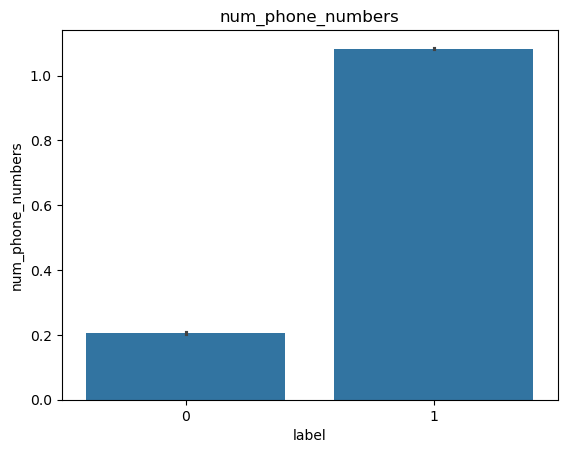

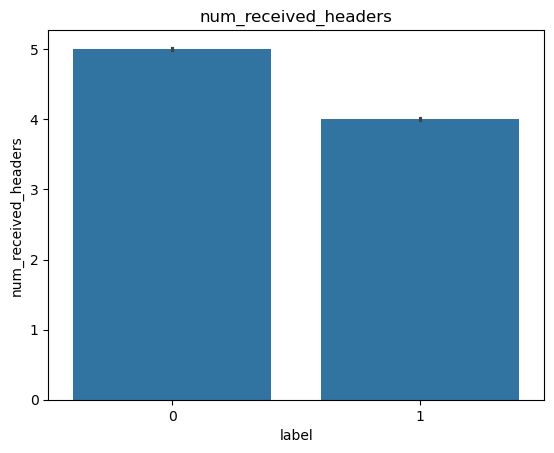

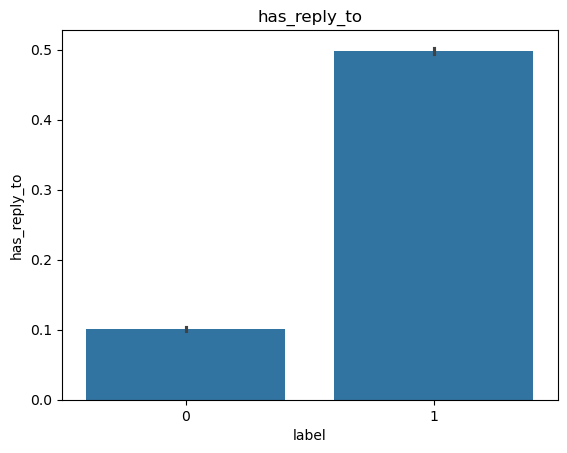

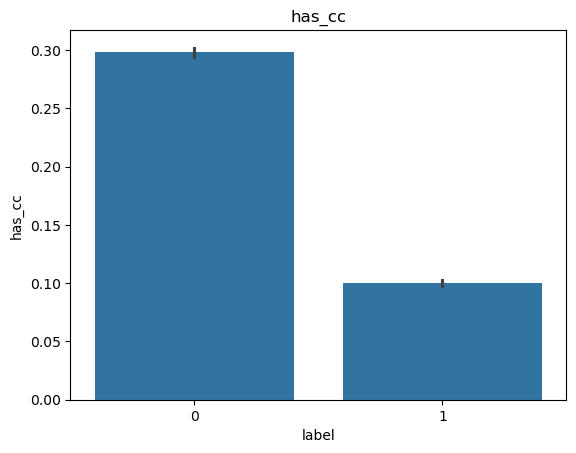

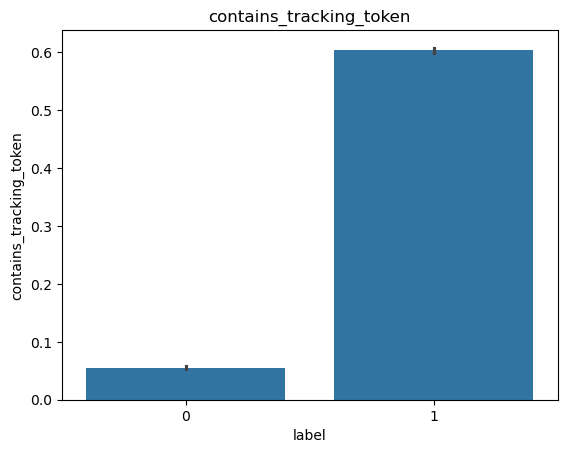

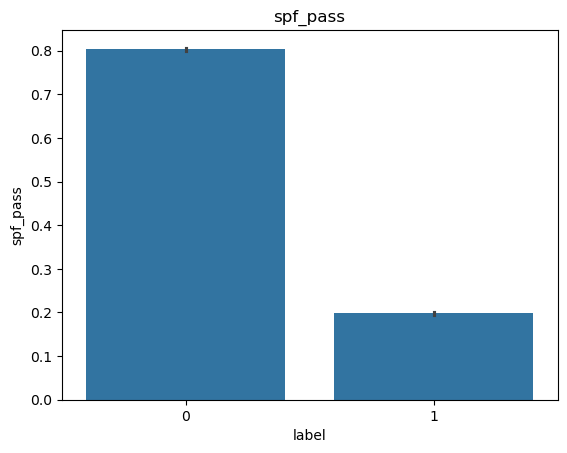

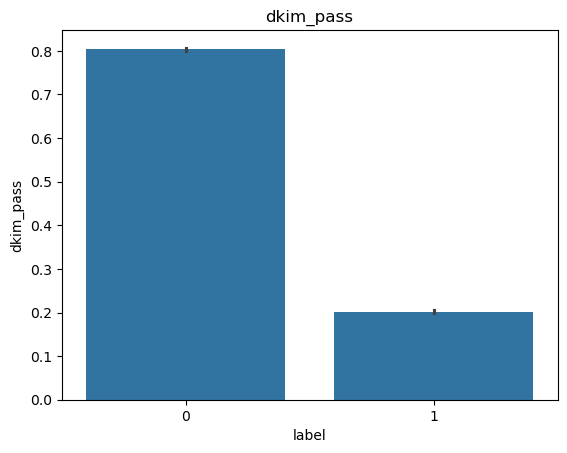

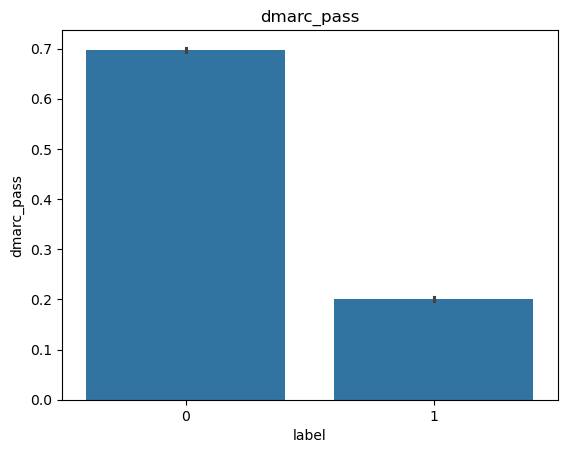

In [15]:
# Wizualizacje
from matplotlib import pyplot as plt
import seaborn as sns

top_features = [
    'num_phone_numbers',
    'num_received_headers',
    'has_reply_to',
    'has_cc',
    'contains_tracking_token',
    'spf_pass',
    'dkim_pass',
    'dmarc_pass'
]

for col in top_features:
    sns.barplot(x='label', y=col, data=df)
    plt.title(col)
    plt.show()

Wnioski:
- Analiza wizualna potwierdziła wyniki uzyskane podczas porównania średnich oraz analizy zależności. Wiadomości spam/phishing częściej zawierają numery telefonów, pola Reply-To oraz tracking tokeny, natomiast wiadomości legit częściej posiadają większą liczbę nagłówków Received, odbiorców w polu CC oraz poprawnie przechodziły mechanizmy autoryzacji SPF, DKIM i DMARC. Otrzymane wyniki wskazują, że zarówno cechy związane z bezpieczeństwem infrastruktury email, jak i cechy charakterystyczne dla socjotechniki stanowią wartościowe źródło informacji w procesie wykrywania phishingu i spamu.

In [16]:
# Korelacje
corr = df.corr(numeric_only=True)
corr['label'].sort_values(ascending=False)

label                      1.000000
num_phone_numbers          0.787945
contains_tracking_token    0.576457
has_reply_to               0.429039
has_html                   0.354552
has_html_body              0.354552
has_attachments            0.122461
hour_of_day               -0.002720
has_cc                    -0.250474
num_received_headers      -0.333829
dmarc_pass                -0.500078
dkim_pass                 -0.601629
spf_pass                  -0.604978
Name: label, dtype: float64

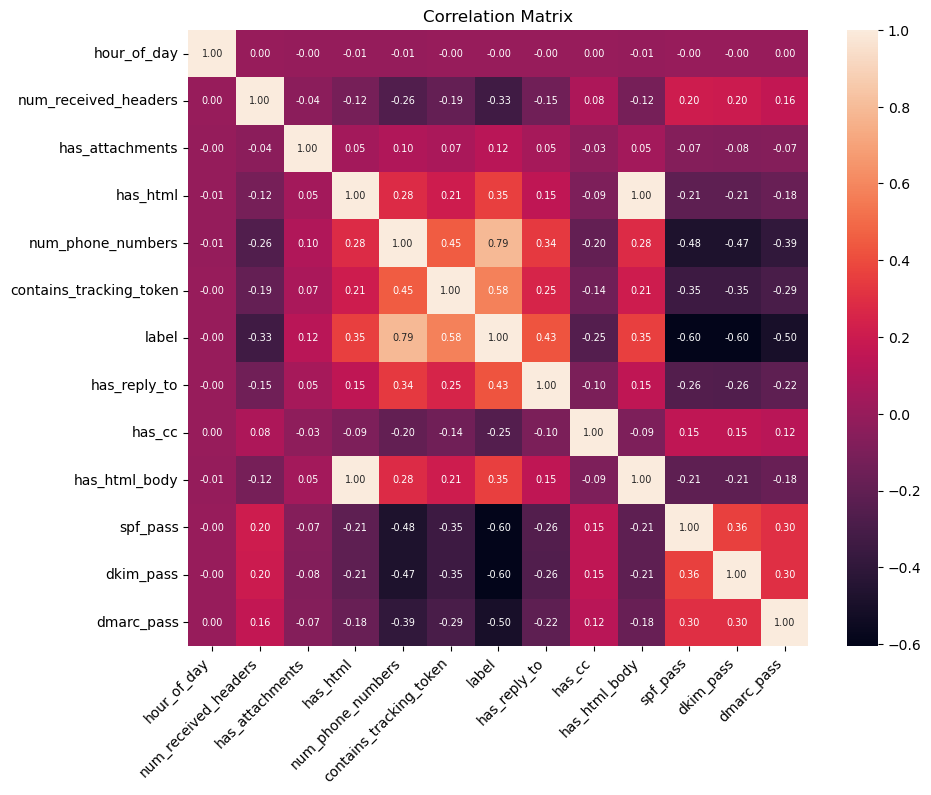

In [17]:
# Korelacje
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size':7},
    fmt='.2f'
)
plt.xticks(rotation=45, ha='right')
plt.title("Correlation Matrix")
plt.show()

Wnioski:
- Analiza korelacji wykazała, że najsilniej dodatnio z klasą spam/phishing (label) były związane cechy 'num_phone_numbers' (0.79), 'contains_tracking_token' (0.58) oraz 'has_reply_to' (0.43). Oznacza to, że wiadomości phishingowe częściej zawierały numery telefonów, mechanizmy śledzenia użytkownika oraz pola Reply-To. Dodatnią korelację wykazywały również 'has_html_body' (0.35) i 'has_attachments' (0.12), sugerując częstsze wykorzystywanie formatowania HTML oraz załączników w wiadomościach spam. Najsilniejsze ujemne korelacje z klasą label odnotowano dla 'spf_pass' (-0.60), 'dkim_pass' (-0.60), 'dmarc_pass' (-0.50) oraz 'num_received_headers' (-0.33), co wskazuje, że wiadomości poprawnie przechodzące mechanizmy autoryzacji domeny i posiadające bardziej rozbudowaną ścieżkę przesyłu były częściej wiadomościami legit. Wyniki korelacji potwierdziły wcześniejsze obserwacje z analizy średnich i wizualizacji, wskazując na dużą wartość predykcyjną cech związanych z bezpieczeństwem infrastruktury email oraz elementami socjotechniki.

In [18]:
# Usuwamy kolumny o tym samym znaczeniu lub nic nie wnoszące
df = df.drop(columns=['has_html', 'hour_of_day'])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95109 entries, 0 to 95108
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   raw_text                 95109 non-null  object
 1   subject                  95109 non-null  object
 2   body_plain               95109 non-null  object
 3   body_html                41140 non-null  object
 4   from_address             95109 non-null  object
 5   from_domain              95109 non-null  object
 6   reply_to                 29442 non-null  object
 7   to_addresses             95109 non-null  object
 8   cc_addresses             18432 non-null  object
 9   date                     95109 non-null  object
 10  message_id               95109 non-null  object
 11  in_reply_to              13526 non-null  object
 12  num_received_headers     95109 non-null  int64 
 13  received_origin_ip       95109 non-null  object
 14  spf_result               95109 non-nul

In [20]:
df

,raw_text,subject,body_plain,body_html,from_address,from_domain,reply_to,to_addresses,cc_addresses,date,...,list_unsubscribe,language,label,has_reply_to,has_cc,has_html_body,spf_pass,dkim_pass,dmarc_pass,text
0,"Subject: Release notes v2.6.4\nDear Vik,\n\nWe...",Release notes v2.6.4,"Dear Vik,\n\nWe received invoice 765713. It wi...",NaN,leo.wilson@adatum.net,adatum.net,NaN,kathy_taylor@notifications.net,NaN,2024-09-13T16:25:32,...,NaN,en,0,0,0,0,0,0,0,"Release notes v2.6.4 Dear Vik,\n\nWe received ..."
1,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour parcel has been flagged. To...",NaN,riya_miller313@proton.me,proton.me,NaN,olivia_wilson841@accounts-mail.com,NaN,2024-07-10T01:15:32,...,NaN,en,1,0,0,0,1,0,0,"WINNER! Claim your reward Dear user,\n\nYour p..."
2,"Subject: Follow-up: onboarding tasks\nHi Zack,...",Follow-up: onboarding tasks,"Hi Zack,\n\nHere are the notes from our meetin...",NaN,wendytaylor@cohosu.org,cohosu.org,NaN,vikwilliams@contoso.com,NaN,2024-04-23T16:20:32,...,NaN,de,0,0,0,0,1,1,1,"Follow-up: onboarding tasks Hi Zack,\n\nHere a..."
3,Subject: Limited-time offer: $119 cloud storag...,Limited-time offer: $119 cloud storage,"Attention Bob,\n\nWe detected unusual activity...",<html><body><h3>Limited-time offer: $119 cloud...,vik.brown@outlook.com,outlook.com,carol.johnson@icloud.com,carol.rodriguez@devops.local,NaN,2024-06-07T19:15:32,...,NaN,it,1,1,0,1,0,0,0,Limited-time offer: $119 cloud storage Attenti...
4,"Subject: Weekly update - Legal\nTeam,\n\nNotes...",Weekly update - Legal,"Team,\n\nNotes from Legal daily standup attach...","<p>Team,<br/><br/>Notes from Legal daily stand...",grace_taylor@globalbank.com,globalbank.com,NaN,leo_wilson@notifications.net,NaN,2024-07-05T11:33:32,...,NaN,it,0,0,0,1,1,1,1,"Weekly update - Legal Team,\n\nNotes from Lega..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95104,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour cloud storage has been flag...",<html><body><h3>WINNER! Claim your reward</h3>...,jack_smith@fabrikam.io,fabrikam.io,NaN,paul.johnson@globalbank.com,NaN,2024-08-05T15:08:52,...,NaN,fr,1,0,0,1,0,0,0,"WINNER! Claim your reward Dear user,\n\nYour c..."
95105,Subject: Holiday calendar and office closure\n...,Holiday calendar and office closure,"Hello Kathy,\n\nOrder 744796 has shipped. Trac...",NaN,quinn.taylor741@example.com,example.com,NaN,yasminsmith@cohosu.org,NaN,2024-08-01T07:25:52,...,NaN,fr,0,0,0,0,1,1,1,Holiday calendar and office closure Hello Kath...
95106,"Subject: WINNER! Claim your reward\nHello,\n\n...",WINNER! Claim your reward,"Hello,\n\nYour parcel (ID 120958) could not be...",<html><body><h3>WINNER! Claim your reward</h3>...,jack.jones@fabrikam.io,fabrikam.io,franktaylor@gmail.com,wendy_taylor@contoso.com,NaN,2024-07-28T13:25:52,...,NaN,en,1,1,0,1,0,0,0,"WINNER! Claim your reward Hello,\n\nYour parce..."
95107,Subject: You received a secure message\nAttent...,You received a secure message,"Attention Bob,\n\nWe detected unusual activity...",NaN,tom_taylor@yahoo.com,yahoo.com,uma_taylor@gmail.com,carol.taylor@cohosu.org,NaN,2024-06-11T04:00:52,...,NaN,en,1,1,0,0,0,0,0,"You received a secure message Attention Bob,\n..."


ML

Cel analizy:
- Porównanie skuteczności trzech popularnych algorytmów klasyfikacyjnych: Logistic Regression, Random Forest oraz XGBoost w zadaniu wykrywania wiadomości jako spam/phishing. Dodatkowo będzie sprawdzone, jak na wyniki klasyfikacji wpływa rodzaj wykorzystywanych danych wejściowych. W tym celu przeprowadzone zostaną trzy eksperymenty:
    - wykorzystujący wyłącznie metadata wiadomości email (Metadata only),
    - wykorzystujący wyłącznie treść wiadomości (Text only),
    - wykorzystujący połączenie metadata i treści wiadomości (Metadata + Text).

    Analiza będzie miała na celu określenie, które źródło informacji dostarcza największej wartości predykcyjnej, oraz który z badanych modeli najlepiej radzi sobie z klasyfikacją wiadomości email.

In [21]:
# Zestaw cech: Metadata vs Text vs Metadata + Text
numeric_features = [
    #'num_emails_in_body',
    'num_phone_numbers',
    'num_received_headers',
    'has_attachments',
    'has_reply_to',
    'has_cc',
    'has_html_body',
    'contains_tracking_token',
    'spf_pass',
    'dkim_pass',
    'dmarc_pass'
]

categorical_features = [
    'language'
]

text_feature = 'text'

y = df['label']

In [22]:
# Import
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    #roc_curve,
    #auc,
    #precision_recall_curve
)

import matplotlib.pyplot as plt
import pandas as pd

In [23]:
# Funkcja do metryk
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, pos_label=1),
        recall_score(y_true, y_pred, pos_label=1),
        f1_score(y_true, y_pred, pos_label=1),
        precision_score(y_true, y_pred, pos_label=0),
        recall_score(y_true, y_pred, pos_label=0),
        f1_score(y_true, y_pred, pos_label=0)
    ]

In [24]:
# Modele
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
}

In [25]:
# Funkcja eksperymentu
def run_experiment(experiment_name, X, preprocessor):
    
    print("\n" + "#" * 100)
    print(f"EXPERIMENT: {experiment_name}")
    print("#" * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    experiment_results = []

    for model_name, model in models.items():
        print("\n" + "=" * 80)
        print(model_name)
        print("=" * 80)

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        
        # Dla ROC/PR
        #y_proba = pipeline.predict_proba(X_test)[:, 1]

        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['SPAM', 'OK']
        )

        disp.plot(cmap='Blues', values_format='d')
        plt.title(f"{experiment_name} - {model_name}")
        plt.show()


        #if model_name == 'XGBoost':
        # ROC
        #fpr, tpr, _ = roc_curve(y_test, y_proba)
        #roc_auc = auc(fpr, tpr)

        #plt.figure()
        #plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
        #plt.plot([0,1],[0,1],'--')
        #plt.xlabel("False Positive Rate")
        #plt.ylabel("True Positive Rate")
        #plt.title(f"ROC Curve - {experiment_name} - {model_name}")
        #plt.legend()
        #plt.show()

        # PR
        #precision, recall, _ = precision_recall_curve(y_test, y_proba)

        #plt.figure()
        #plt.plot(recall, precision)
        #plt.xlabel("Recall")
        #plt.ylabel("Precision")
        #plt.title(f"PR Curve - {experiment_name} - {model_name}")
        #plt.show()


        experiment_results.append(
        [experiment_name, model_name] + get_metrics(y_test, y_pred))

    return experiment_results


####################################################################################################
EXPERIMENT: Metadata only
####################################################################################################

LogisticRegression
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      9022
           1       0.97      0.98      0.97     10000

    accuracy                           0.97     19022
   macro avg       0.97      0.97      0.97     19022
weighted avg       0.97      0.97      0.97     19022



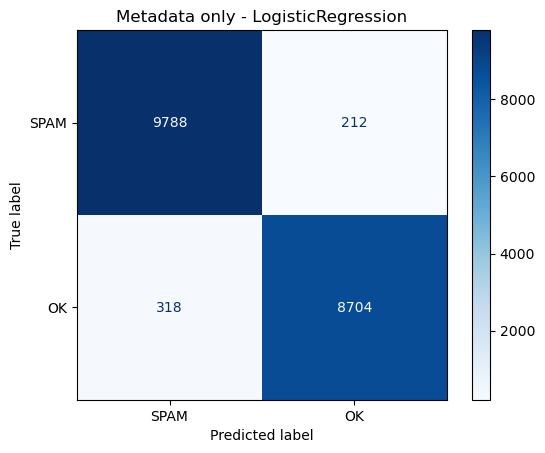


RandomForest
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      9022
           1       0.97      0.98      0.98     10000

    accuracy                           0.97     19022
   macro avg       0.97      0.97      0.97     19022
weighted avg       0.97      0.97      0.97     19022



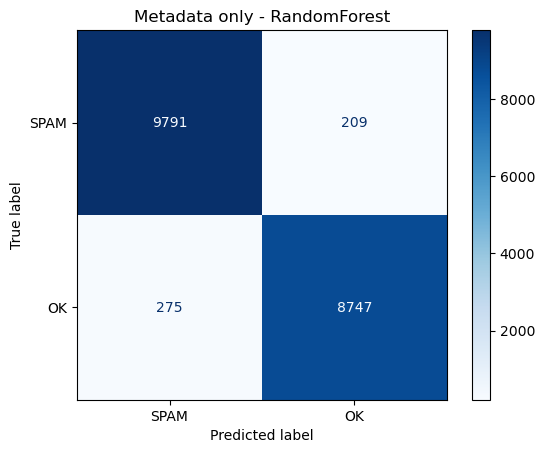


XGBoost
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      9022
           1       0.97      0.98      0.98     10000

    accuracy                           0.98     19022
   macro avg       0.98      0.98      0.98     19022
weighted avg       0.98      0.98      0.98     19022



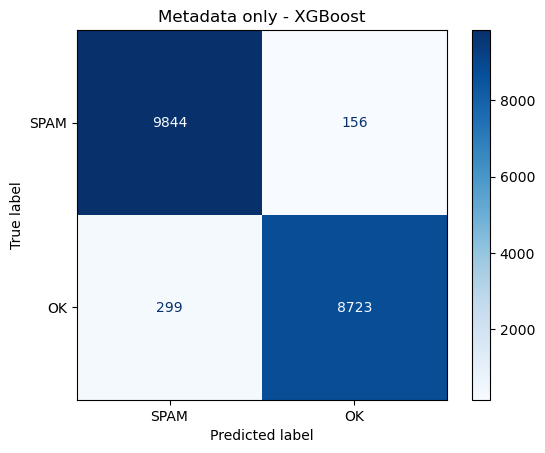

In [26]:
# Eksperyment 1: Tylko Metadata
X_metadata = df[
    numeric_features +
    categorical_features
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_metadata = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

results_metadata = run_experiment(
    'Metadata only',
    X_metadata,
    preprocessor_metadata
)


####################################################################################################
EXPERIMENT: Text only
####################################################################################################

LogisticRegression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9022
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     19022
   macro avg       1.00      1.00      1.00     19022
weighted avg       1.00      1.00      1.00     19022



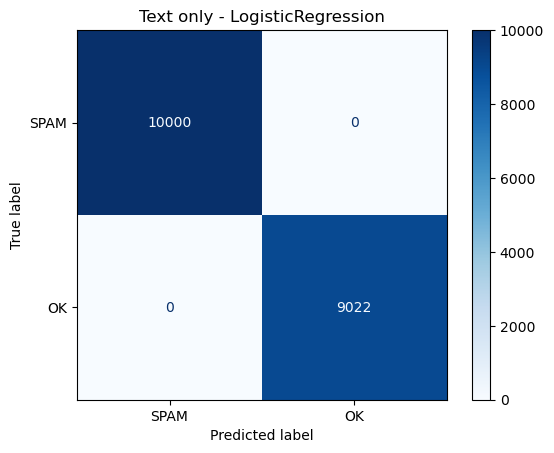


RandomForest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9022
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     19022
   macro avg       1.00      1.00      1.00     19022
weighted avg       1.00      1.00      1.00     19022



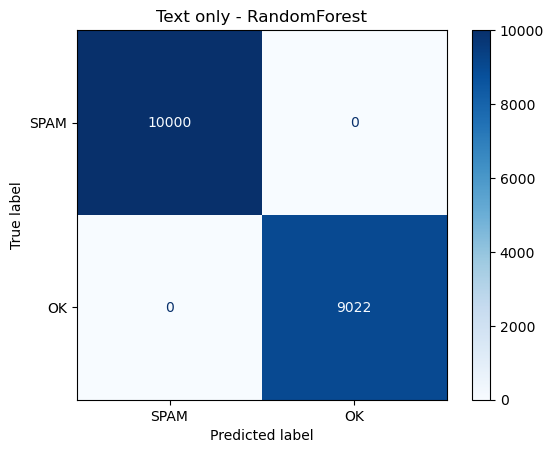


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9022
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     19022
   macro avg       1.00      1.00      1.00     19022
weighted avg       1.00      1.00      1.00     19022



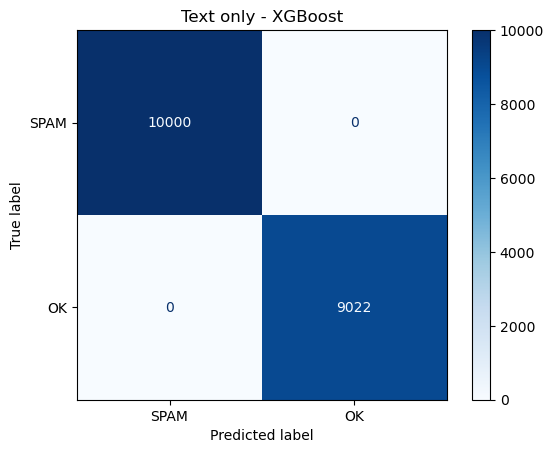

In [27]:
# Eksperyment 2: Tylko Text
X_text = df[[text_feature]]

preprocessor_text = ColumnTransformer([
    ('txt', TfidfVectorizer(
        max_features=10000,
        stop_words='english',
        ngram_range=(1,2),
        min_df=3
    ), text_feature)
])

results_text = run_experiment(
    'Text only',
    X_text,
    preprocessor_text
)



####################################################################################################
EXPERIMENT: Metadata + Text
####################################################################################################

LogisticRegression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9022
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     19022
   macro avg       1.00      1.00      1.00     19022
weighted avg       1.00      1.00      1.00     19022



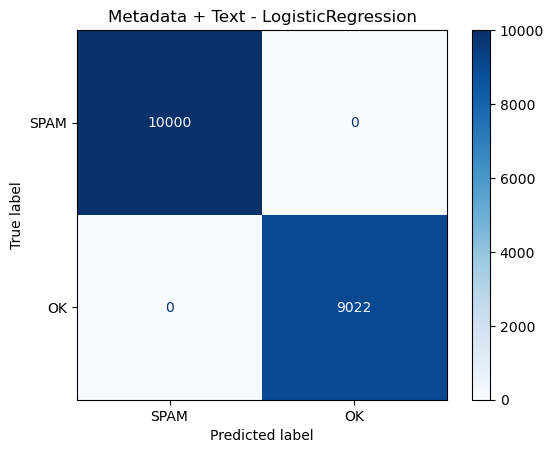


RandomForest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9022
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     19022
   macro avg       1.00      1.00      1.00     19022
weighted avg       1.00      1.00      1.00     19022



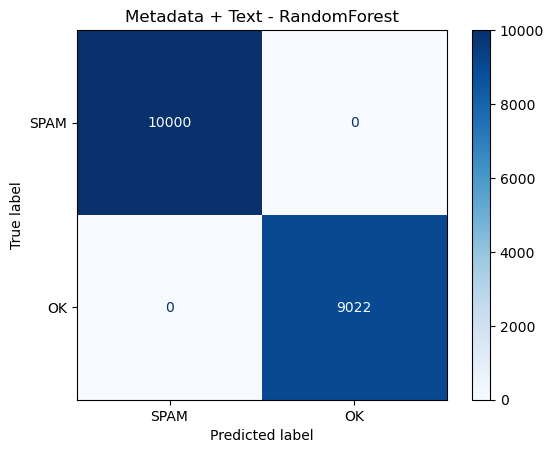


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9022
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     19022
   macro avg       1.00      1.00      1.00     19022
weighted avg       1.00      1.00      1.00     19022



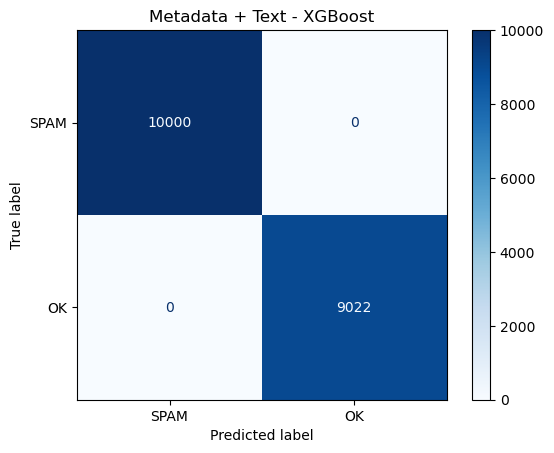

In [28]:
# Eksperyment 3: Metadata + Text
X_combined = df[
    numeric_features +
    categorical_features +
    [text_feature]
]

preprocessor_combined = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('txt', TfidfVectorizer(
            max_features=10000,
            stop_words='english',
            ngram_range=(1, 2),
            min_df=3
        ), text_feature)
    ],
    transformer_weights={
        'num': 1.0,
        'cat': 1.0,
        'txt': 7.0
    }
)

results_combined = run_experiment(
    'Metadata + Text',
    X_combined,
    preprocessor_combined
)

In [29]:
# Finalne wyniki
all_results = results_metadata + results_text + results_combined

results_df = pd.DataFrame(
    all_results,
    columns=[
        'Experiment',
        'Model',
        'Accuracy',
        'Precision SPAM',
        'Recall SPAM',
        'F1 SPAM',
        'Precision OK',
        'Recall OK',
        'F1 OK'
    ]
)

results_df.round(3)

,Experiment,Model,Accuracy,Precision SPAM,Recall SPAM,F1 SPAM,Precision OK,Recall OK,F1 OK
0,Metadata only,LogisticRegression,0.972,0.969,0.979,0.974,0.976,0.965,0.970
1,Metadata only,RandomForest,0.975,0.973,0.979,0.976,0.977,0.970,0.973
2,Metadata only,XGBoost,0.976,0.971,0.984,0.977,0.982,0.967,0.975
3,Text only,LogisticRegression,1.000,1.000,1.000,1.000,1.000,1.000,1.000
4,Text only,RandomForest,1.000,1.000,1.000,1.000,1.000,1.000,1.000
5,Text only,XGBoost,1.000,1.000,1.000,1.000,1.000,1.000,1.000
6,Metadata + Text,LogisticRegression,1.000,1.000,1.000,1.000,1.000,1.000,1.000
7,Metadata + Text,RandomForest,1.000,1.000,1.000,1.000,1.000,1.000,1.000
8,Metadata + Text,XGBoost,1.000,1.000,1.000,1.000,1.000,1.000,1.000


Wniosek:
- Przeprowadzone eksperymenty wykazały, że zarówno metadata wiadomości email, jak i ich treść zawierają istotne informacje umożliwiające wykrywanie phishingu i spamu. Najwyższą skuteczność osiągnięto dla modeli wykorzystujących tekst wiadomości, które uzyskały 100% Accuracy, a także nie popełniły żadnego błędu klasyfikacji na zbiorze testowym, niezależnie od zastosowanego algorytmu. Dodanie metadata do warstwy tekstowej nie poprawiło wyników, co wskazuje, że informacje zawarte w treści wiadomości były wystarczające do poprawnej klasyfikacji. Wśród modeli opartych wyłącznie na metadata najlepsze wyniki osiągnął XGBoost, jednak różnice względem pozostałych modeli były niewielkie. Wyniki sugerują, że tekst wiadomości stanowi najważniejsze źródło informacji w analizowanym zbiorze danych.

Cel dalszej analizy:
- Po przeprowadzeniu eksperymentów dla trzech zestawów cech (Metadata only, Text only oraz Metadata + Text), uzyskano bardzo wysokie wyniki klasyfikacji, sięgające nawet 100% Accuracy dla modeli wykorzystujących tekst wiadomości. Tak wysokie rezultaty mogły jednak wynikać z konkretnego podziału danych na zbiór treningowy i testowy. Dlatego kolejnym krokiem będzie walidacja krzyżowa (5-Fold Cross-Validation), która sprawdzi, czy uzyskane wyniki są stabilne i powtarzalne dla różnych podziałów danych. Walidacja krzyżowa pozwolil zweryfikować zdolność modeli do generalizacji oraz potwierdzić, że wysoka skuteczność nie była efektem przypadkowego doboru próbek w pojedynczym eksperymencie train/test split.

In [30]:
# Cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [31]:
# Funkcja do CV
def run_cv_experiment(experiment_name, X, preprocessor):

    print("\n" + "#" * 100)
    print(f"CROSS-VALIDATION: {experiment_name}")
    print("#" * 100)

    cv_results = []

    for model_name, model in models.items():

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=cv,
            scoring='accuracy',
            n_jobs=-1
        )

        print(f"\n{model_name}")
        print(f"Fold accuracy: {scores}")
        print(f"Mean accuracy: {scores.mean():.4f}")
        print(f"Std: {scores.std():.4f}")

        cv_results.append([
            experiment_name,
            model_name,
            scores.mean(),
            scores.std()
        ])

    return cv_results

In [32]:
# Tylko Metadata
cv_metadata = run_cv_experiment(
    'Metadata only',
    X_metadata,
    preprocessor_metadata
)


####################################################################################################
CROSS-VALIDATION: Metadata only
####################################################################################################

LogisticRegression
Fold accuracy: [0.97203238 0.97276837 0.97297866 0.97339922 0.97192577]
Mean accuracy: 0.9726
Std: 0.0006

RandomForest
Fold accuracy: [0.97376722 0.97445064 0.97403007 0.97424035 0.97208349]
Mean accuracy: 0.9737
Std: 0.0008

XGBoost
Fold accuracy: [0.97555462 0.97834087 0.97597519 0.97723688 0.97586878]
Mean accuracy: 0.9766
Std: 0.0010


In [33]:
# Tylko Text
cv_text = run_cv_experiment(
    'Text only',
    X_text,
    preprocessor_text
)


####################################################################################################
CROSS-VALIDATION: Text only
####################################################################################################

LogisticRegression
Fold accuracy: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Std: 0.0000

RandomForest
Fold accuracy: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Std: 0.0000

XGBoost
Fold accuracy: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Std: 0.0000


In [34]:
# Metadata + Text
cv_combined = run_cv_experiment(
    'Metadata + Text',
    X_combined,
    preprocessor_combined
)


####################################################################################################
CROSS-VALIDATION: Metadata + Text
####################################################################################################

LogisticRegression
Fold accuracy: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Std: 0.0000

RandomForest
Fold accuracy: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Std: 0.0000

XGBoost
Fold accuracy: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Std: 0.0000


In [35]:
# Finalna tabela 
cv_all = cv_metadata + cv_text + cv_combined

cv_results_df = pd.DataFrame(
    cv_all,
    columns=[
        'Experiment',
        'Model',
        'Mean Accuracy',
        'Std'
    ]
)

cv_results_df.round(4)

,Experiment,Model,Mean Accuracy,Std
0,Metadata only,LogisticRegression,0.9726,0.0006
1,Metadata only,RandomForest,0.9737,0.0008
2,Metadata only,XGBoost,0.9766,0.0010
3,Text only,LogisticRegression,1.0000,0.0000
4,Text only,RandomForest,1.0000,0.0000
5,Text only,XGBoost,1.0000,0.0000
6,Metadata + Text,LogisticRegression,1.0000,0.0000
7,Metadata + Text,RandomForest,1.0000,0.0000
8,Metadata + Text,XGBoost,1.0000,0.0000


Wniosek:
- Wyniki walidacji krzyżowej potwierdziły wcześniejsze obserwacje. Modele wykorzystujące wyłącznie metadata osiągały skuteczność przekraczającą 97%, przy czym najlepsze wyniki ponownie uzyskał XGBoost. Z kolei modele wykorzystujące tekst wiadomości oraz połączenie tekstu i metadata osiągnęły 100% średniej dokładności we wszystkich foldach. Bardzo niskie wartości odchylenia standardowego wskazują, że uzyskane wyniki były stabilne i niezależne od konkretnego podziału danych. Oznacza to, że wcześniejsze wnioski dotyczące wysokiej wartości predykcyjnej warstwy tekstowej zostały potwierdzone również podczas walidacji krzyżowej. Bardzo niskie wartości odchylenia standardowego świadczą o wysokiej stabilności modeli oraz niewielkiej zależności wyników od konkretnego podziału danych na foldy.

Cel dalszej analizy:
- Po przeprowadzeniu walidacji krzyżowej wybrano model XGBoost do dalszej analizy interpretowalności, ponieważ osiągnął najlepsze wyniki w eksperymencie Metadata only. Następnie zostanie zbudowany pipeline zawierający preprocessing metadanych oraz klasyfikator XGBoost, aby sprawdzić, które cechy metadata miały największy wpływ na decyzje modelu. Analiza Feature Importance pozwoli ocenić znaczenie poszczególnych zmiennych i lepiej zrozumieć, na jakich sygnałach model opierał klasyfikację wiadomości spam/phishing i legit.

In [36]:
# Pipeline: preprocessing metadanych + klasyfikator XGBoost

# Model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor_metadata),
    ('model', xgb_model)
])

# Trenowanie
pipeline.fit(X_metadata, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
# Pobranie nazw cech po preprocessingu oraz ich ważności z modelu XGBoost
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = pipeline.named_steps[
    'model'
].feature_importances_

In [38]:
# DataFrame - utworzenie tabeli ważności cech
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
0,num__num_phone_numbers,0.601058
6,num__contains_tracking_token,0.078096
7,num__spf_pass,0.077599
8,num__dkim_pass,0.072917
9,num__dmarc_pass,0.049536
5,num__has_html_body,0.037494
3,num__has_reply_to,0.037136
1,num__num_received_headers,0.031122
4,num__has_cc,0.009796
2,num__has_attachments,0.003937


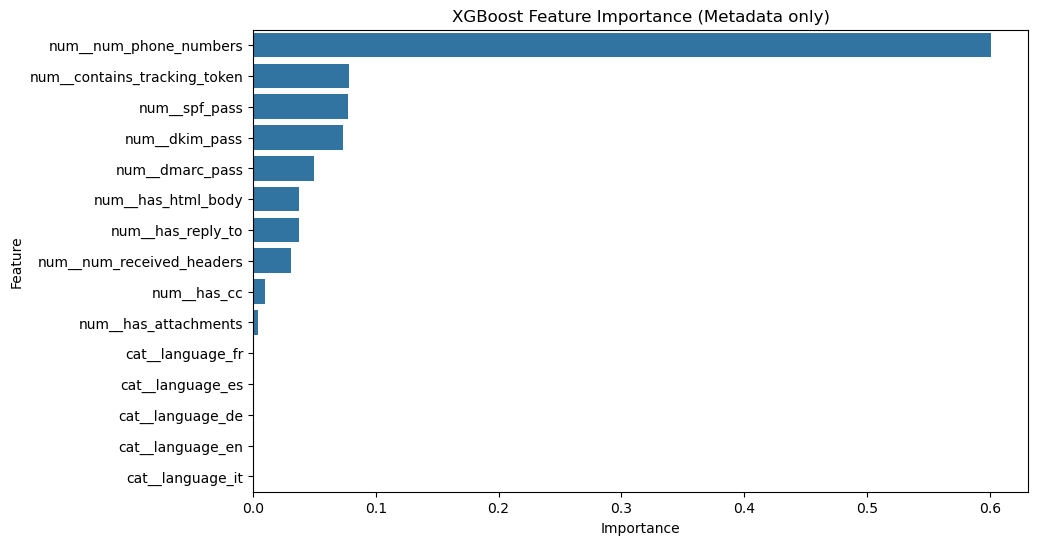

In [39]:
# Top 15 cech
top_n = 15

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(top_n),
    x='Importance',
    y='Feature'
)

plt.title('XGBoost Feature Importance (Metadata only)')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Wniosek:
- Analiza Feature Importance wykazała, że najważniejszą cechą wykorzystywaną przez model XGBoost była zmienna 'num_phone_numbers', co wskazuje, że była bardzo silnym sygnałem wiadomości spam/phishing. Odpowiadała za 60% całkowitego znaczenia cech. Istotną rolę odgrywały również tracking tokeny oraz mechanizmy autoryzacji SPF, DKIM i DMARC. Z kolei zmienna 'language' miała praktycznie zerowy wpływ na klasyfikację. Wyniki potwierdziły wcześniejsze obserwacje z EDA i korelacji, wskazując, że zarówno elementy socjotechniczne, jak i cechy bezpieczeństwa infrastruktury email stanowią kluczowe źródło informacji w procesie wykrywania.

Cel dalszej analizy:
- Analiza Feature Importance wykazała, że cecha 'num_phone_numbers' była zdecydowanie najważniejszą zmienną wykorzystywaną przez model XGBoost. W związku z tym, kolejnym krokiem będzie przeprowadzonie eksperymentu polegającego na usunięciu tej cechy, aby ocenić jej rzeczywisty wpływ na skuteczność klasyfikacji.

In [40]:
# Eksperyment:

# Wybór cech metadanych bez cechy 'num_phone_numbers'
numeric_features_no_phone = [
    'num_received_headers',
    'has_attachments',
    'has_reply_to',
    'has_cc',
    'has_html_body',
    'contains_tracking_token',
    'spf_pass',
    'dkim_pass',
    'dmarc_pass'
]

categorical_features = [
    'language'
]

X_metadata_no_phone = df[
    numeric_features_no_phone +
    categorical_features
]

In [41]:
# Preprocessing cech liczbowych i kategorycznych
numeric_transformer_no_phone = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_no_phone = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_no_phone = ColumnTransformer([
    ('num', numeric_transformer_no_phone, numeric_features_no_phone),
    ('cat', categorical_transformer_no_phone, categorical_features)
])

In [42]:
# Cross-validation dla metadanych bez num_phone_numbers
cv_no_phone = run_cv_experiment(
    'Metadata WITHOUT num_phone_numbers',
    X_metadata_no_phone,
    preprocessor_no_phone
)


####################################################################################################
CROSS-VALIDATION: Metadata WITHOUT num_phone_numbers
####################################################################################################

LogisticRegression
Fold accuracy: [0.93102723 0.93349805 0.93465461 0.93307749 0.93370485]
Mean accuracy: 0.9332
Std: 0.0012

RandomForest
Fold accuracy: [0.93807171 0.93780885 0.94138366 0.93617916 0.93943536]
Mean accuracy: 0.9386
Std: 0.0017

XGBoost
Fold accuracy: [0.94133109 0.94169909 0.94422248 0.94101567 0.94322065]
Mean accuracy: 0.9423
Std: 0.0012


In [43]:
# Rezultaty
cv_no_phone_df = pd.DataFrame(
    cv_no_phone,
    columns=[
        'Experiment',
        'Model',
        'Mean Accuracy',
        'Std'
    ]
)

cv_no_phone_df.round(4)

,Experiment,Model,Mean Accuracy,Std
0,Metadata WITHOUT num_phone_numbers,LogisticRegression,0.9332,0.0012
1,Metadata WITHOUT num_phone_numbers,RandomForest,0.9386,0.0017
2,Metadata WITHOUT num_phone_numbers,XGBoost,0.9423,0.0012


Wniosek:
- Eksperyment potwierdził, że 'num_phone_numbers' była najważniejszą cechą wykorzystywaną podczas klasyfikacji wiadomości email. Jej usunięcie spowodowało spadek skuteczności wszystkich modeli o około 3–4 punkty %. Jednocześnie modele nadal osiągały wysokie wyniki przekraczające 93% Accuracy, co dowodzi, że skuteczna klasyfikacja była możliwa również na podstawie pozostałych cech związanych z bezpieczeństwem email i charakterystycznymi elementami wiadomości phishingowych. Niskie wartości odchylenia standardowego wskazują, że modele zachowały wysoką stabilność również po usunięciu najważniejszej cechy.

Cel dalszej analizy:
- Analiza Feature Importance potwierdziła, że wszystkie kategorie zmiennej 'language' otrzymały bardzo niskie wartości importance. W związku z tym pojawiło się pytanie:
Czy zmienna 'language' rzeczywiście wnosi dodatkową wartość do klasyfikacji wiadomości email, czy też model osiąga podobne wyniki bez informacji o języku wiadomości? Dlatego przeprowadzono eksperyment polegający na całkowitym usunięciu cechy language i ponownym przeprowadzeniu walidacji krzyżowej.

In [44]:
# Eksperyment:

# Wybór cech metadanych bez cechy language
numeric_features_no_language = [
    'num_phone_numbers',
    'num_received_headers',
    'has_attachments',
    'has_reply_to',
    'has_cc',
    'has_html_body',
    'contains_tracking_token',
    'spf_pass',
    'dkim_pass',
    'dmarc_pass'
]

X_metadata_no_language = df[
    numeric_features_no_language
]

In [45]:
# Preprocessing cech liczbowych
numeric_transformer_no_language = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_no_language = ColumnTransformer([
    ('num', numeric_transformer_no_language, numeric_features_no_language)
])

In [46]:
# Cross-validation dla metadanych bez language
cv_no_language = run_cv_experiment(
    'Metadata WITHOUT language',
    X_metadata_no_language,
    preprocessor_no_language
)


####################################################################################################
CROSS-VALIDATION: Metadata WITHOUT language
####################################################################################################

LogisticRegression
Fold accuracy: [0.97187467 0.9730838  0.97266323 0.9730838  0.97213606]
Mean accuracy: 0.9726
Std: 0.0005

RandomForest
Fold accuracy: [0.97550205 0.97728945 0.97581747 0.97676375 0.97508017]
Mean accuracy: 0.9761
Std: 0.0008

XGBoost
Fold accuracy: [0.97555462 0.97834087 0.97581747 0.97713174 0.9758162 ]
Mean accuracy: 0.9765
Std: 0.0011


In [47]:
# Resultaty
cv_no_language_df = pd.DataFrame(
    cv_no_language,
    columns=[
        'Experiment',
        'Model',
        'Mean Accuracy',
        'Std'
    ]
)

cv_no_language_df.round(4)

,Experiment,Model,Mean Accuracy,Std
0,Metadata WITHOUT language,LogisticRegression,0.9726,0.0005
1,Metadata WITHOUT language,RandomForest,0.9761,0.0008
2,Metadata WITHOUT language,XGBoost,0.9765,0.0011


Wniosek:
- Eksperyment wykazał, że zmienna 'language' nie miała istotnego wpływu na skuteczność klasyfikacji wiadomości email. Usunięcie tej cechy nie spowodowało spadku Accuracy żadnego z modeli, co potwierdziło wcześniejsze wyniki analizy Feature Importance. Oznacza to, że informacje o języku wiadomości nie wnosiły dodatkowej wartości predykcyjnej, a decyzje modeli były podejmowane głównie na podstawie pozostałych cech metadata związanych z bezpieczeństwem i strukturą wiadomości email. Modele zachowały wysoką stabilność również po usunięciu zmiennej 'language', co dodatkowo potwierdza niewielkie znaczenie tej cechy.

Cel dalszej analizy:
- W poprzednich etapach projektu wykazano, że modele wykorzystujące treść wiadomości (Text only) osiągały najwyższą skuteczność klasyfikacji, uzyskując 100% Accuracy zarówno podczas eksperymentów, jak i walidacji krzyżowej. W związku z tym kolejnym krokiem była interpretacja warstwy tekstowej modelu. Celem analizy było zidentyfikowanie słów i fraz, które najsilniej wpływały na klasyfikację wiadomości jako spam/phishing lub legit. W tym celu wykorzystano współczynniki modelu Logistic Regression trenowanego na reprezentacji TF-IDF, co pozwoliło określić najważniejsze słowa charakterystyczne dla obu klas.

- Dlaczego wybrano model Logistic Regression, do analizy najważniejszych słów? Ponieważ pozwala on łatwo sprawdzić, które słowa zwiększają prawdopodobieństwo zaklasyfikowania wiadomości jako spam/phishing, a które są charakterystyczne dla wiadomości legit. W przeciwieństwie do Random Forest i XGBoost, model ten przypisuje każdemu słowu konkretną wagę (współczynnik), dzięki czemu można bezpośrednio wskazać najważniejsze słowa wpływające na decyzję modelu.

- Natomiast: Random Forest składa się ze setek drzew decyzyjnych, XGBoost buduje wiele kolejnych drzew, więc one potrafią powiedzieć: które cechy są ważne, ale dużo trudniej odpowiedzieć: które konkretne słowo zwiększa prawdopodobieństwo spamu. Dlatego do analizy najważniejszych słów wykorzystano Logistic Regression, ponieważ model ten jest najbardziej przejrzysty i pozwala bezpośrednio interpretować wpływ poszczególnych słów na wynik klasyfikacji. Dzięki temu możliwe było wskazanie słów charakterystycznych dla wiadomości spam/phishing oraz wiadomości legit.

In [48]:
# Przygotowanie danych do analizy najważniejszych słów w tekście (NLP Explainability - Natural Language Processing)
X_text = df['text']
y_text = df['label']

In [49]:
# Pipeline dla klasyfikacji tekstu (TF – term frequency, IDF – inverse document frequency)
nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        stop_words='english',
        ngram_range=(1,2),
        min_df=3
    )),
    ('model', LogisticRegression(max_iter=1000))
])

In [50]:
# Trenowanie modelu tekstowego na danych X_text i etykietach y_text
nlp_pipeline.fit(X_text, y_text)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [51]:
# Pobranie słów i fraz utworzonych przez TfidfVectorizer
feature_names = nlp_pipeline.named_steps[
    'tfidf'
].get_feature_names_out()

In [52]:
# Coefficients
coefficients = nlp_pipeline.named_steps[
    'model'
].coef_[0]

coef_df = pd.DataFrame({
    'Word': feature_names,
    'Coefficient': coefficients
})

In [53]:
# Top spam words
top_spam_words = coef_df.sort_values(
    by='Coefficient',
    ascending=False
).head(20)

print("\nTOP SPAM WORDS")
display(top_spam_words)


TOP SPAM WORDS


,Word,Coefficient
6557,https,6.644176
8948,ref,5.333291
9690,verify,4.791832
4555,account,4.119556
5812,confirm,3.833014
5577,billing,3.740373
7055,offer,3.705559
6785,limited,2.951293
6571,id,2.923554
7445,parcel,2.852016


In [54]:
# Top legit words
top_legit_words = coef_df.sort_values(
    by='Coefficient',
    ascending=True
).head(20)

print("\nTOP LEGIT WORDS")
display(top_legit_words)


TOP LEGIT WORDS


,Word,Coefficient
9414,thanks,-4.684994
9079,review,-4.070743
6990,notes,-3.761344
9807,weekly,-3.391296
5550,best,-3.115105
5480,attached,-3.113779
6480,hi,-3.008773
1445,2024,-2.908267
1476,2025,-2.805055
9011,reminder,-2.701920


Wniosek:
- Analiza najważniejszych słów wyjaśniła, dlaczego modele wykorzystujące treść wiadomości osiągały wysoką skuteczność. Klasy spam/phishing i legit różniły się słownictwem, co ułatwiało modelowi odróżnianie obu grup wiadomości. Analiza NLP wykazała, że model opierał się na wzorcach językowych charakterystycznych dla phishingu i spamu, takich jak logowanie, weryfikacja konta, płatności, nagrody czy pilne działania. Wiadomości legit zawierały natomiast słownictwo typowe dla zwykłej komunikacji biznesowej.

- Ostatni etap to przedstawienie finalnego modelu, którego klasyfikacja została oparty nie tylko na tekście, ale też o metadane o cechach technicznych wiadomoścu, takich jak np. SPF, DKIM, DMARC, HTML, załączniki czy liczba nagłówków Received. Pozwoli to lepiej odwzoroować rzeczywistą ocenę wiadomości email.

In [55]:
# Finalny model do testów
import joblib

X = df[
    numeric_features +
    categorical_features +
    [text_feature]
]

y = df['label']

final_model = Pipeline([
    ('preprocessor', preprocessor_combined),
    ('model', LogisticRegression(max_iter=1000))
])

final_model.fit(X, y)

joblib.dump(final_model, 'spam_metadata_text_model.pkl')

['spam_metadata_text_model.pkl']

In [56]:
# Wczytanie modelu
model = joblib.load('spam_metadata_text_model.pkl')

In [57]:
# Funkcja testująca
def predict_email_full(
    subject,
    body,
    language='en',
    num_phone_numbers=0,
    num_received_headers=1,
    has_attachments=0,
    has_reply_to=0,
    has_cc=0,
    has_html_body=1,
    contains_tracking_token=0,
    spf_pass=1,
    dkim_pass=1,
    dmarc_pass=1
):
    subject = subject if subject is not None else ''
    body = body if body is not None else ''

    text = subject + ' ' + body

    new_email = pd.DataFrame([{
        'num_phone_numbers': num_phone_numbers,
        'num_received_headers': num_received_headers,
        'has_attachments': has_attachments,
        'has_reply_to': has_reply_to,
        'has_cc': has_cc,
        'has_html_body': has_html_body,
        'contains_tracking_token': contains_tracking_token,
        'spf_pass': spf_pass,
        'dkim_pass': dkim_pass,
        'dmarc_pass': dmarc_pass,
        'language': language,
        'text': text
    }])

    # Prawdopodobieństwo ML
    probabilities = model.predict_proba(new_email)[0]
    #probabilities = [round(p, 3) for p in probabilities]
    probabilities_display = [float(f"{p:.10f}") for p in probabilities]

    print("Klasy modelu:", model.classes_)
    print("Prawdopodobieństwa:", probabilities_display)

    spam_index = list(model.classes_).index(1)
    spam_probability = probabilities[spam_index]


    # Thresholds
    spam_threshold = 0.75

    if spam_probability >= spam_threshold:
        label = "SPAM / PHISHING"
    else:
        label = "LEGIT"

    return {
        'prediction': label,
        'spam_probability': round(float(spam_probability), 4)
    }

In [58]:
predict_email_full(
    subject="Weekly meeting notes",
    body="Hi, attached are the notes from our weekly meeting.",
    has_attachments=1,
    has_html_body=0,
    contains_tracking_token=0,
    spf_pass=1,
    dkim_pass=1,
    dmarc_pass=1
)

Klasy modelu: [0 1]
Prawdopodobieństwa: [0.9998518044, 0.0001481956]


{'prediction': 'LEGIT', 'spam_probability': 0.0001}

In [59]:
predict_email_full(
    subject="WINNER! Verify your account immediately",
    body="""
    Dear user,

    Your account has been flagged. To restore access, click the link below:
    https://update.info/billing/94332769

    Failure to act may result in account closure.
    Support
    """,
    language='en',
    num_phone_numbers=1,
    num_received_headers=5,
    has_attachments=0,
    has_reply_to=0,
    has_cc=0,
    has_html_body=2,
    contains_tracking_token=0,
    spf_pass=1,
    dkim_pass=1,
    dmarc_pass=1
)

Klasy modelu: [0 1]
Prawdopodobieństwa: [0.0008319363, 0.9991680637]


{'prediction': 'SPAM / PHISHING', 'spam_probability': 0.9992}

In [60]:
predict_email_full(
    subject="URGENT! Your account has been flagged",
    body="""
    Dear user,

    We detected unusual activity on your account.
    To restore access, click the link below:
    https://update.info/account/58291403

    Failure to act may result in account closure.
    Support Team
    """,
    language='en',
    num_phone_numbers=1,
    num_received_headers=5,
    has_attachments=0,
    has_reply_to=0,
    has_cc=0,
    has_html_body=0,
    contains_tracking_token=0,
    spf_pass=1,
    dkim_pass=0,
    dmarc_pass=0
)

Klasy modelu: [0 1]
Prawdopodobieństwa: [0.000540572, 0.999459428]


{'prediction': 'SPAM / PHISHING', 'spam_probability': 0.9995}

In [61]:
predict_email_full(
    subject="Payment confirmation required for invoice #73921",
    body="""
    Dear user,

    Your invoice payment could not be verified.
   
    Billing Department
    """,
    language='en',
    num_phone_numbers=1,
    num_received_headers=0,
    has_attachments=0,
    has_reply_to=0,
    has_cc=1,
    has_html_body=1,
    contains_tracking_token=0,
    spf_pass=1,
    dkim_pass=0,
    dmarc_pass=0
)

Klasy modelu: [0 1]
Prawdopodobieństwa: [0.123836002, 0.876163998]


{'prediction': 'SPAM / PHISHING', 'spam_probability': 0.8762}

In [62]:
predict_email_full(
    subject="Release notes v2.6.4",
    body="""
    Dear Vik,

    We received invoice 765713. It will be processed by Accounts Payable.

    Best,
    Wendy
    """
)

Klasy modelu: [0 1]
Prawdopodobieństwa: [0.9999960113, 3.9887e-06]


{'prediction': 'LEGIT', 'spam_probability': 0.0}

In [63]:
predict_email_full(
    subject="WINNER! Claim your reward",
    body="""
    FINAL ALERT: Your account will be closed in 24 hours. Keep your cloud storage active by logging in:
    https://login-kvwo.app/track/37918602-gcrpp
    Ref: request-OPA0715967
    """
)

Klasy modelu: [0 1]
Prawdopodobieństwa: [0.0594048096, 0.9405951904]


{'prediction': 'SPAM / PHISHING', 'spam_probability': 0.9406}